<a href="https://colab.research.google.com/github/keerthanashajip-spec/NorthStar-Data-Analytics/blob/main/notebooks/NorthStar_MongoDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility — MongoDB Atlas
## Section: NoSQL Database Design + CRUD + Aggregation

Objective: Design and implement a MongoDB database to handle
complex nested operational records that relational systems
cannot manage effectively.

Collections: customers, orders, drivers, hubs, vehicles, complaints

In [65]:
!pip install pymongo

In [66]:
from pymongo import MongoClient

uri = "mongodb+srv://YOUR_USERNAME:YOUR_PASSWORD:AEWVwEc5YpgpAeyT@cluster0.jvoelgg.mongodb.net/"

client = MongoClient(uri)

print("Connected to MongoDB Atlas")

Connected to MongoDB Atlas


In [67]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/My Drive/Colab Notebooks/"
print("Drive mounted successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully


In [68]:
import pandas as pd
import numpy as np

deliveries = pd.read_csv(path + "deliveries.csv")
orders = pd.read_csv(path + "orders.csv")
customers = pd.read_csv(path + "customers.csv")
drivers = pd.read_csv(path + "drivers.csv")
complaints = pd.read_csv(path + "complaints.csv")
hubs = pd.read_csv(path + "hubs.csv")
vehicles = pd.read_csv(path + "vehicles.csv")

print("All datasets loaded")

All datasets loaded


In [69]:
import json

def dataframe_to_mongo(df):
    df = df.replace({np.nan: None})
    json_str = df.to_json(orient='records')
    return json.loads(json_str)

print("Helper function ready")

Helper function ready


### Create Database

In [70]:
db = client["northstar_db"]
print("Database 'northstar_db' created/selected")

Database 'northstar_db' created/selected


### Drop Collections

In [71]:
collections = ["customers", "orders", "drivers",
               "complaints", "hubs", "vehicles",
               "deliveries", "incidents", "app_events"]

for col in collections:
    db[col].drop()

print("All collections cleared")

All collections cleared


## NoSQL Schema Design

MongoDB is used because NorthStar data is:
- Nested (complaint history, event sequences)
- Dynamic (different fields per entity)
- Event-driven (delivery tracking, incidents)

Relational systems require joins, but MongoDB allows:
- Embedded documents for fast access
- Flexible schema evolution
- Single-document retrieval for complex objects


## Embedded vs Referenced Design Decisions

EMBEDDED:
- complaints → event_sequence  
  Reason: Complaint history is always accessed together  

- orders → delivery details  
  Reason: Delivery is part of the same lifecycle  

REFERENCED:
- customer_id in orders  
  Reason: Customers exist independently  

- driver_id in orders  
  Reason: Drivers handle multiple orders  

WHY NOSQL:
- Handles nested and dynamic data  
- Avoids complex joins  
- Stores full operational records in one document

#####Insert All Collections

In [72]:
# Customers
customers_docs = dataframe_to_mongo(customers)
db["customers"].insert_many(customers_docs)
print("Customers inserted:", len(customers_docs))

# Orders
orders_docs = dataframe_to_mongo(orders)
db["orders"].insert_many(orders_docs)
print("Orders inserted:", len(orders_docs))

# Drivers
drivers_docs = dataframe_to_mongo(drivers)
db["drivers"].insert_many(drivers_docs)
print("Drivers inserted:", len(drivers_docs))

# Complaints
complaints_docs = dataframe_to_mongo(complaints)
db["complaints"].insert_many(complaints_docs)
print("Complaints inserted:", len(complaints_docs))

# Hubs
hubs_docs = dataframe_to_mongo(hubs)
db["hubs"].insert_many(hubs_docs)
print("Hubs inserted:", len(hubs_docs))

# Vehicles
vehicles_docs = dataframe_to_mongo(vehicles)
db["vehicles"].insert_many(vehicles_docs)
print("Vehicles inserted:", len(vehicles_docs))

Customers inserted: 650
Orders inserted: 1250
Drivers inserted: 170
Complaints inserted: 320
Hubs inserted: 8
Vehicles inserted: 120


Add Nested Event Sequence

In [73]:
for doc in complaints_docs:
    doc["event_sequence"] = [
        {
            "event": "ComplaintRaised",
            "timestamp": str(doc.get("created_at")),
            "note": "Complaint registered"
        }
    ]

db["complaints"].drop()
db["complaints"].insert_many(complaints_docs)

print("Complaints updated with nested event_sequence")

Complaints updated with nested event_sequence


####Merge Orders with Deliveries

In [74]:
orders_merged = orders.merge(deliveries, on="order_id", how="left")

orders_docs = dataframe_to_mongo(orders_merged)

db["orders"].drop()
db["orders"].insert_many(orders_docs)

print("Orders now include delivery info")

Orders now include delivery info


####CRUD operations

In [75]:
# CRUD - READ (FIND)

print("=== FIND 1: Failed Deliveries ===")
failed = db["orders"].find(
    {"delivery_status": "Failed"},   # correct (after merge)
    {"order_id": 1, "pickup_zone": 1,
     "delivery_status": 1, "_id": 0}
)
for doc in list(failed)[:5]:
    print(doc)

print("\n=== FIND 2: High Severity Complaints ===")
high = db["complaints"].find(
    {"severity": "High"},
    {"complaint_id": 1, "complaint_type": 1,
     "customer_id": 1, "compensation_amount": 1,
     "_id": 0}
)
for doc in list(high)[:5]:
    print(doc)

print("\n=== FIND 3: Active FullTime Drivers ===")
active = db["drivers"].find(
    {"employment_type": "FullTime", "active_flag": 1},
    {"driver_id": 1, "base_zone": 1,
     "driver_rating": 1, "_id": 0}
)
for doc in list(active)[:5]:
    print(doc)

print("\n=== FIND 4: High Value Orders ===")
high_orders = db["orders"].find(
    {"order_value": {"$gt": 200}},
    {"order_id": 1, "customer_id": 1,
     "order_value": 1, "_id": 0}
)
for doc in list(high_orders)[:5]:
    print(doc)

=== FIND 1: Failed Deliveries ===
{'order_id': 'O00023', 'pickup_zone': 'north', 'delivery_status': 'Failed'}
{'order_id': 'O00031', 'pickup_zone': 'EAST', 'delivery_status': 'Failed'}
{'order_id': 'O00033', 'pickup_zone': 'NORTH', 'delivery_status': 'Failed'}
{'order_id': 'O00035', 'pickup_zone': 'north', 'delivery_status': 'Failed'}
{'order_id': 'O00070', 'pickup_zone': 'Ctr', 'delivery_status': 'Failed'}

=== FIND 2: High Severity Complaints ===
{'complaint_id': 'CP0001', 'customer_id': 'C0464', 'complaint_type': 'AppIssue', 'compensation_amount': 23.99}
{'complaint_id': 'CP0003', 'customer_id': 'C0469', 'complaint_type': 'Delay', 'compensation_amount': 26.41}
{'complaint_id': 'CP0008', 'customer_id': 'C0309', 'complaint_type': 'AppIssue', 'compensation_amount': None}
{'complaint_id': 'CP0012', 'customer_id': 'C0362', 'complaint_type': 'AppIssue', 'compensation_amount': 33.8}
{'complaint_id': 'CP0020', 'customer_id': 'C0371', 'complaint_type': 'DriverBehaviour', 'compensation_amount

In [76]:
# CRUD - UPDATE

print("=== UPDATE 1: Update complaint status ===")
result1 = db["complaints"].update_one(
    {"complaint_id": "CP0001"},
    {"$set": {"status": "Resolved", "resolution_days": 5}}
)
print("Matched:", result1.matched_count, "Modified:", result1.modified_count)

# Verify
updated = db["complaints"].find_one(
    {"complaint_id": "CP0001"},
    {"complaint_id": 1, "status": 1, "_id": 0}
)
print("Verified:", updated)

print("\n=== UPDATE 2: Add event to complaint sequence ===")
result2 = db["complaints"].update_one(
    {"complaint_id": "CP0002"},
    {"$push": {"event_sequence": {
        "event": "Resolved",
        "timestamp": "2024-11-10",
        "note": "Issue resolved"
    }}}
)
print("Modified:", result2.modified_count)

print("\n=== UPDATE 3: Update driver rating ===")
result3 = db["drivers"].update_one(
    {"driver_id": "D001"},
    {"$set": {"driver_rating": 4.0}}
)
print("Modified:", result3.modified_count)

=== UPDATE 1: Update complaint status ===
Matched: 1 Modified: 1
Verified: {'complaint_id': 'CP0001', 'status': 'Resolved'}

=== UPDATE 2: Add event to complaint sequence ===
Modified: 1

=== UPDATE 3: Update driver rating ===
Modified: 1


In [77]:
# CRUD - DELETE

db["complaints"].insert_one({
    "complaint_id": "CP9999",
    "customer_id": "C0001",
    "complaint_type": "Test",
    "severity": "Low",
    "status": "Test"
})

print("Inserted test document")

before = db["complaints"].find_one({"complaint_id": "CP9999"})
print("Before delete:", before is not None)

result = db["complaints"].delete_one({"complaint_id": "CP9999"})
print("Deleted:", result.deleted_count)

after = db["complaints"].find_one({"complaint_id": "CP9999"})
print("After delete exists:", after is not None)

Inserted test document
Before delete: True
Deleted: 1
After delete exists: False


In [78]:
# AGGREGATION PIPELINES

print("=== Complaints by Type ===")
pipeline1 = [
    {"$group": {
        "_id": "$complaint_type",
        "total": {"$sum": 1},
        "avg_comp": {"$avg": "$compensation_amount"}
    }},
    {"$sort": {"total": -1}}
]

for r in db["complaints"].aggregate(pipeline1):
    print(r)


print("\n=== Orders by Service Type ===")
pipeline2 = [
    {"$group": {
        "_id": "$service_type",
        "total": {"$sum": 1},
        "avg_value": {"$avg": "$order_value"}
    }}
]

for r in db["orders"].aggregate(pipeline2):
    print(r)


print("\n=== Delivery Status Count ===")
pipeline3 = [
    {"$group": {
        "_id": "$delivery_status",
        "count": {"$sum": 1}
    }}
]

for r in db["orders"].aggregate(pipeline3):
    print(r)

=== Complaints by Type ===
{'_id': 'Delay', 'total': 101, 'avg_comp': 18.051489361702128}
{'_id': 'MissedPickup', 'total': 64, 'avg_comp': 22.593650793650795}
{'_id': 'AppIssue', 'total': 53, 'avg_comp': 19.6144}
{'_id': 'DriverBehaviour', 'total': 51, 'avg_comp': 21.153478260869566}
{'_id': 'SupportExperience', 'total': 20, 'avg_comp': 17.125}
{'_id': 'Billing', 'total': 16, 'avg_comp': 23.87125}
{'_id': 'Damage', 'total': 15, 'avg_comp': 23.982000000000003}

=== Orders by Service Type ===
{'_id': 'Business', 'total': 165, 'avg_value': 92.2450303030303}
{'_id': 'Passenger', 'total': 341, 'avg_value': 96.07363636363637}
{'_id': 'Medical', 'total': 139, 'avg_value': 87.13618705035971}
{'_id': 'Parcel', 'total': 308, 'avg_value': 87.61564935064935}
{'_id': 'Retail', 'total': 297, 'avg_value': 90.01367003367004}

=== Delivery Status Count ===
{'_id': None, 'count': 300}
{'_id': 'OnTime', 'count': 616}
{'_id': 'Failed', 'count': 132}
{'_id': 'Delayed', 'count': 202}


In [79]:
# Prepare data for charts

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chart 1 data (Complaints)
comp = list(db["complaints"].aggregate([
    {"$group": {"_id": "$complaint_type", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]))
df = pd.DataFrame(comp)

# Chart 2 data (Delivery Status)
status = list(db["orders"].aggregate([
    {"$group": {"_id": "$delivery_status", "count": {"$sum": 1}}}
]))
df2 = pd.DataFrame(status)

print("Chart data prepared")

Chart data prepared


/tmp/ipykernel_1851/3520299536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="_id", y="count", palette="Blues_d")


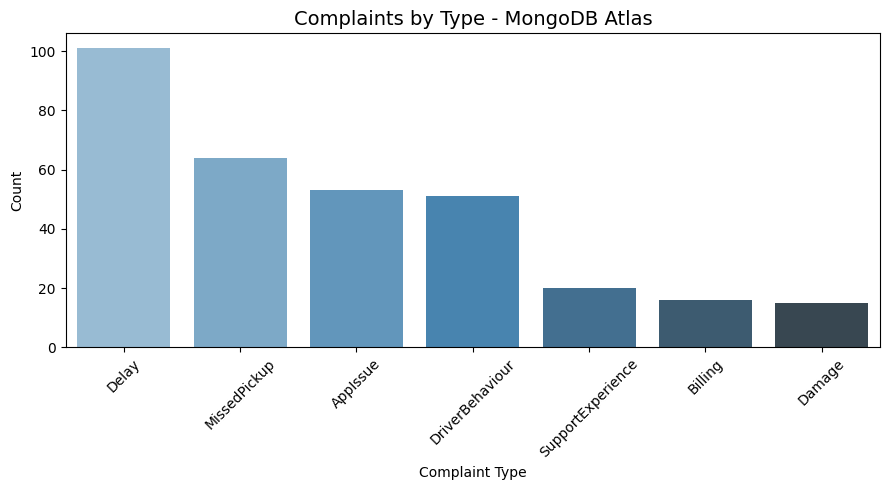

📊 Insight: Delay and MissedPickup complaints dominate


In [80]:
# Chart 1: Complaints by Type

plt.figure(figsize=(9,5))
sns.barplot(data=df, x="_id", y="count", palette="Blues_d")

plt.title("Complaints by Type - MongoDB Atlas", fontsize=14)
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("📊 Insight: Delay and MissedPickup complaints dominate")

/tmp/ipykernel_1851/2047447961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, x="_id", y="count", palette="Set2")


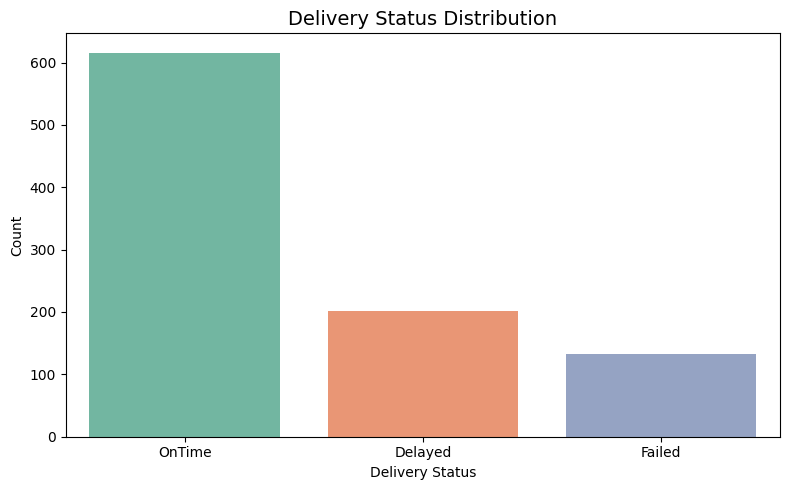

Insight: Failed deliveries indicate operational inefficiency


In [81]:
# Chart 2: Delivery Status

plt.figure(figsize=(8,5))
sns.barplot(data=df2, x="_id", y="count", palette="Set2")

plt.title("Delivery Status Distribution", fontsize=14)
plt.xlabel("Delivery Status")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print("Insight: Failed deliveries indicate operational inefficiency")

/tmp/ipykernel_1851/2098037782.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=driver_df, x="_id", y="avg_rating", palette="Greens_d")


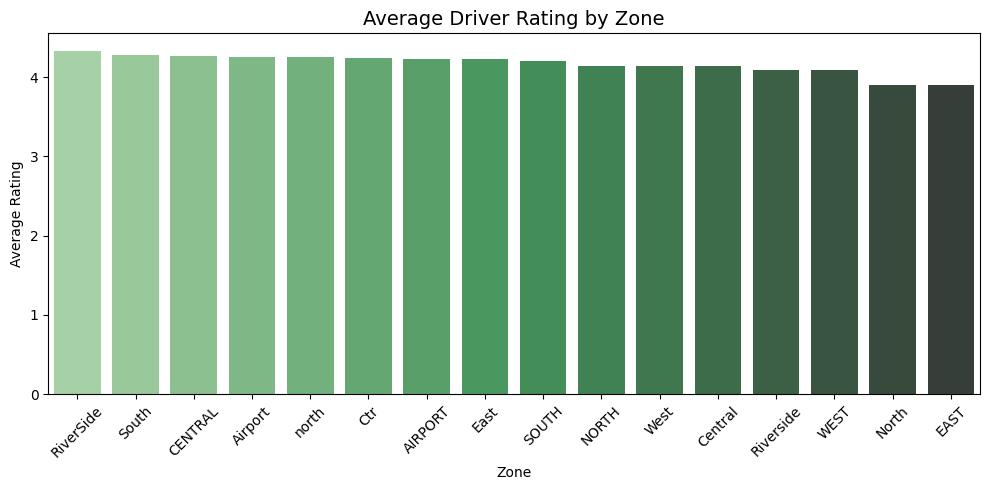

 Insight: Zones with low ratings need training improvement


In [82]:
# Chart 3: Driver Rating by Zone

driver_data = list(db["drivers"].aggregate([
    {"$group": {
        "_id": "$base_zone",
        "avg_rating": {"$avg": "$driver_rating"}
    }},
    {"$sort": {"avg_rating": -1}}
]))

driver_df = pd.DataFrame(driver_data)

plt.figure(figsize=(10,5))
sns.barplot(data=driver_df, x="_id", y="avg_rating", palette="Greens_d")

plt.title("Average Driver Rating by Zone", fontsize=14)
plt.xlabel("Zone")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(" Insight: Zones with low ratings need training improvement")

In [83]:
print("\n=== FINAL COLLECTIONS SUMMARY ===")

for col in db.list_collection_names():
    count = db[col].count_documents({})
    print(f" {col}: {count} documents")


=== FINAL COLLECTIONS SUMMARY ===
 complaints: 320 documents
 hubs: 8 documents
 vehicles: 120 documents
 orders: 1250 documents
 customers: 650 documents
 drivers: 170 documents


MONGODB SECTION COMPLETE

Collections:
- customers
- orders
- drivers
- complaints
- hubs
- vehicles

CRUD Operations:
- INSERT
- READ
- UPDATE
- DELETE

Aggregation:
- Complaints analysis
- Orders analysis
- Delivery status

Charts:
- Complaints by type
- Delivery status
- Driver rating by zone

MongoDB Advantages:
- Handles nested data
- No joins required
- Flexible schema
- Efficient querying


